<a href="https://www.kaggle.com/code/sarazahran1/imdb-sentiment-analysis-project?scriptVersionId=301069424" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

#  **IMDb Sentiment Analysis Project**

#  **Objective:**
Build a sentiment analysis model to classify IMDb movie reviews as *positive* or **negative**



#  **Steps:**
1. Load & explore the data
2. Preprocess the text (cleaning, tokenization, stopwords, lemmatization)
3. Feature extraction (BoW + TF-IDF)
4. Model training (Logistic Regression or SVM)
5. Evaluation
6. POS tagging and NER (optional)
7. Visualization (word cloud, sentiment distribution)

# **Import libraries and read data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load the IMDb dataset
df = pd.read_csv("/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")
df.head()

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# **Text cleaning**

In [2]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()                         # lowercase
    text = re.sub(r'<.*?>', '', text)           # remove HTML tags
    text = re.sub(r'[^a-zA-Z]', ' ', text)      # remove punctuation/numbers
    tokens = word_tokenize(text)                # tokenize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

df['cleaned'] = df['review'].apply(clean_text)
df[['review', 'cleaned']].head()

,review,cleaned
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


 # **Text to Number (TF-IDF)**

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned'])
y = df['sentiment'].map({'positive': 1, 'negative': 0})

# **Model building and evaluation**

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8881
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



# **Word Cloud cell**

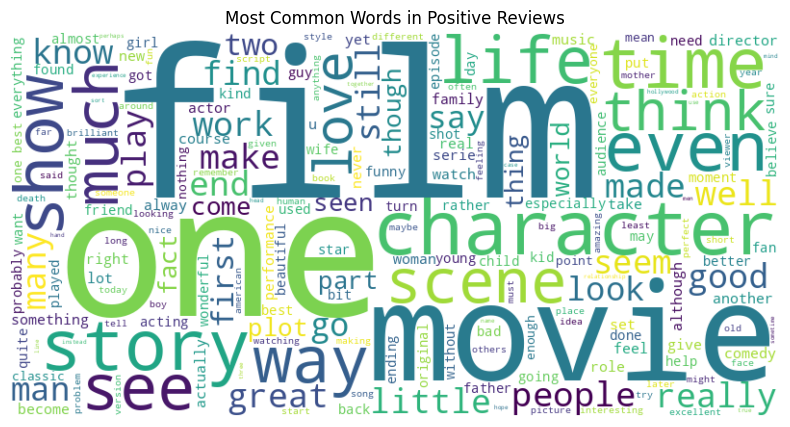

In [5]:
from wordcloud import WordCloud

# WordCloud for positive reviews
positive_text = " ".join(df[df['sentiment'] == 'positive']['cleaned'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in Positive Reviews")
plt.show()

# **POS Tagging + NER (using spaCy)**

In [6]:
import spacy
nlp = spacy.load("en_core_web_sm")

sample_text = df['cleaned'].iloc[0]
doc = nlp(sample_text)

print("POS Tags:")
for token in doc[:15]:
    print(f"{token.text}: {token.pos_}")

print("\nNamed Entities:")
for ent in doc.ents:
    print(f"{ent.text}: {ent.label_}")

POS Tags:
one: NUM
reviewer: NOUN
mentioned: VERB
watching: VERB
oz: ADP
episode: NOUN
hooked: VERB
right: ADV
exactly: ADV
happened: VERB
first: ADJ
thing: NOUN
struck: VERB
oz: ADP
brutality: NOUN

Named Entities:
one: CARDINAL
aryan muslim: PERSON
gangsta: ORG
christian: NORP
italian: NORP
irish: NORP
first: ORDINAL
